# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from itertools import permutations
import seaborn as sns
plt.style.use('default')
plt.rc('figure', figsize = (10,8))
plt.rc('text',usetex=True)
plt.rc('font', size=24)
dataset = 'Fe-Mo/'


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)

In [3]:
BS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,Fe_pv,Mo_sv,EF,Phase
index,,,,,,,,,,,,,,,,,,,,,
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,22,0,30.0,0.266667,0.733333,0.215379,sigma
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,10,20,0,30.0,0.333333,0.666667,0.034391,sigma
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,4,20,0,24.0,0.166667,0.833333,0.479948,C36
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,3,10,0,13.0,0.230769,0.769231,0.30749,mu
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,5,24,0,29.0,0.172414,0.827586,0.457378,chi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,3,10,0,13.0,0.230769,0.769231,0.342791,mu
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,8,22,0,30.0,0.266667,0.733333,0.243743,sigma
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,Mo_sv,,1,3,0,4.0,0.250000,0.750000,0.278125,fcc


# Compositions 

# Population of phases

<AxesSubplot:xlabel='Phase', ylabel='Count'>

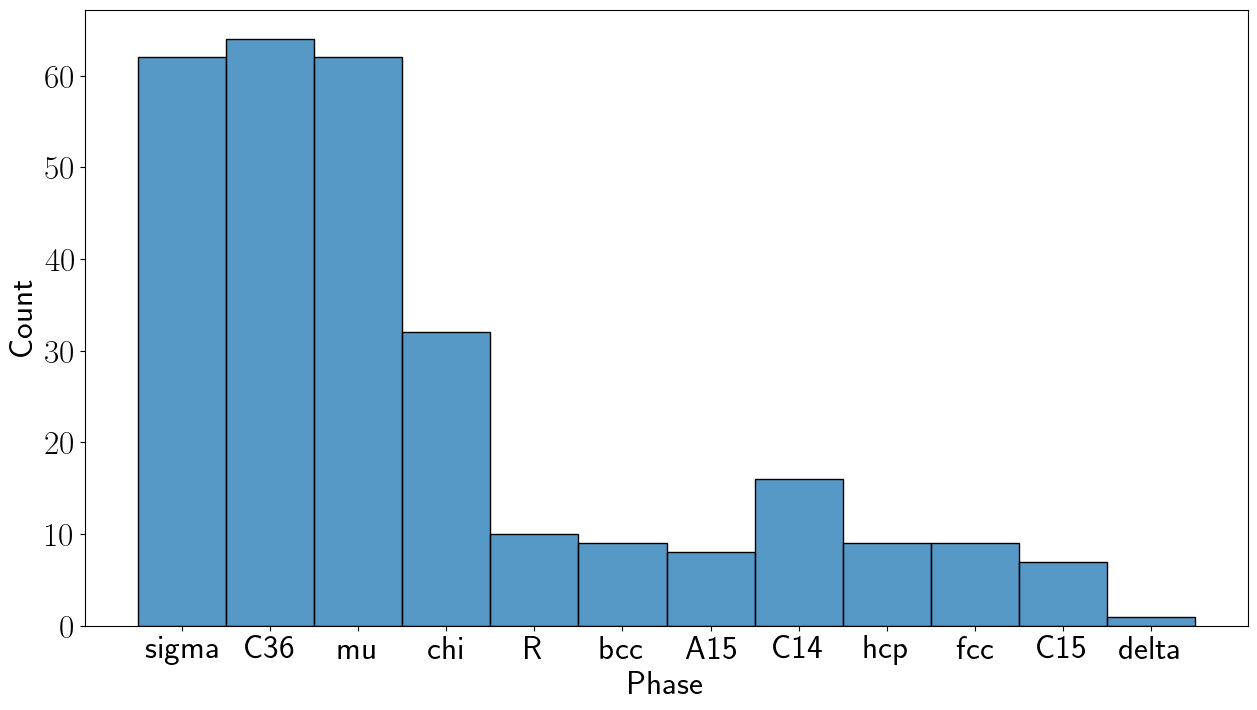

In [4]:
fig, ax = plt.subplots(figsize=(15,8))
sns.histplot(x = BS['Phase'], ax=ax)

#  Obvious outliers removal

In [8]:
BS = BS[(BS.B0 > 0 ) ]

# Distribution of Target Variables 

## total energy

In [9]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

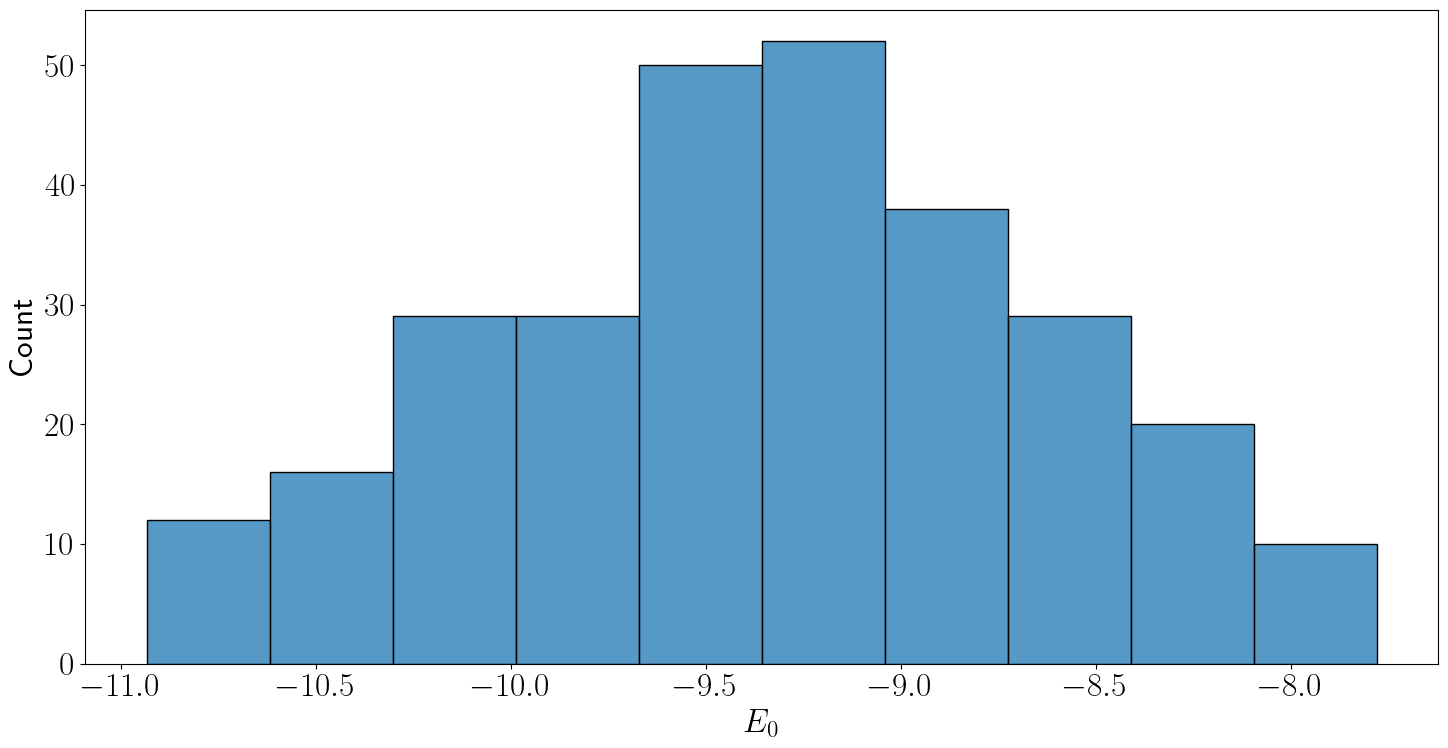

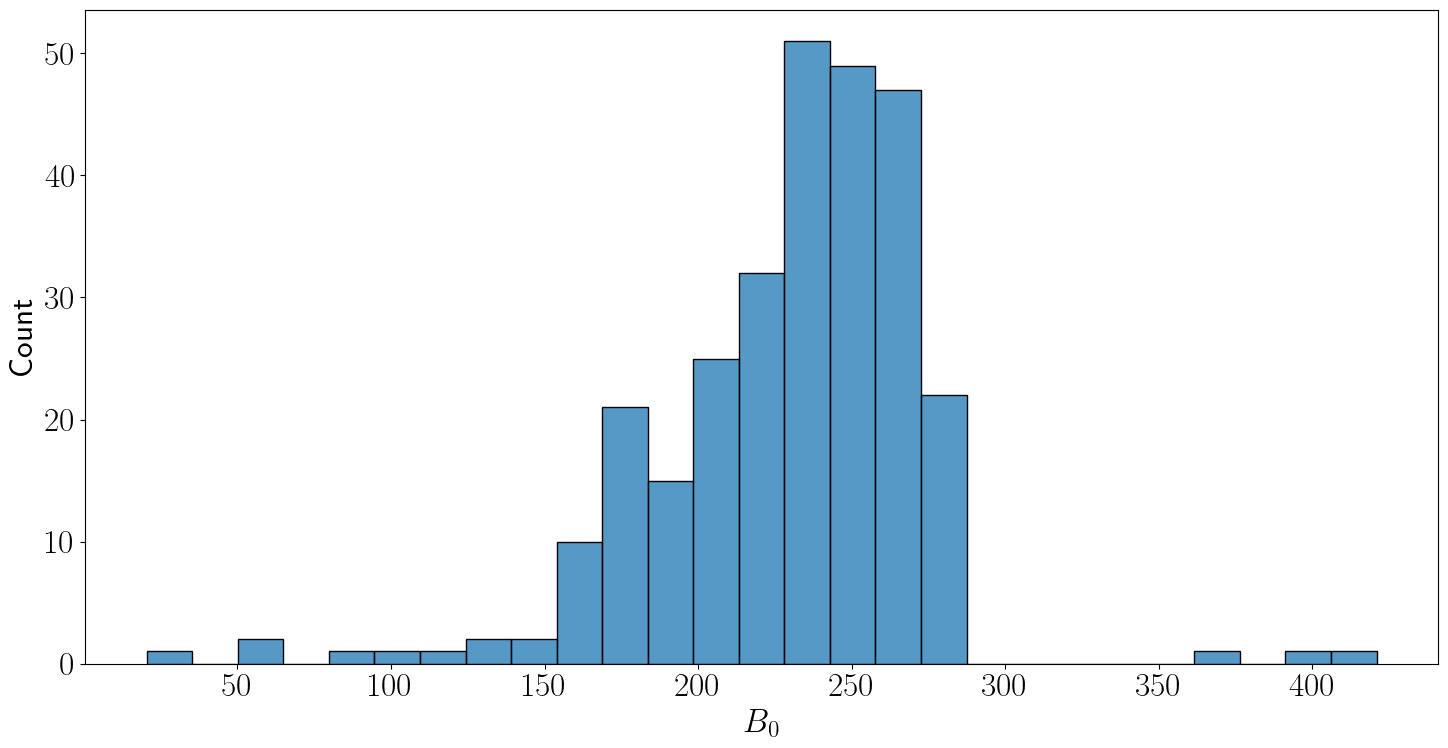

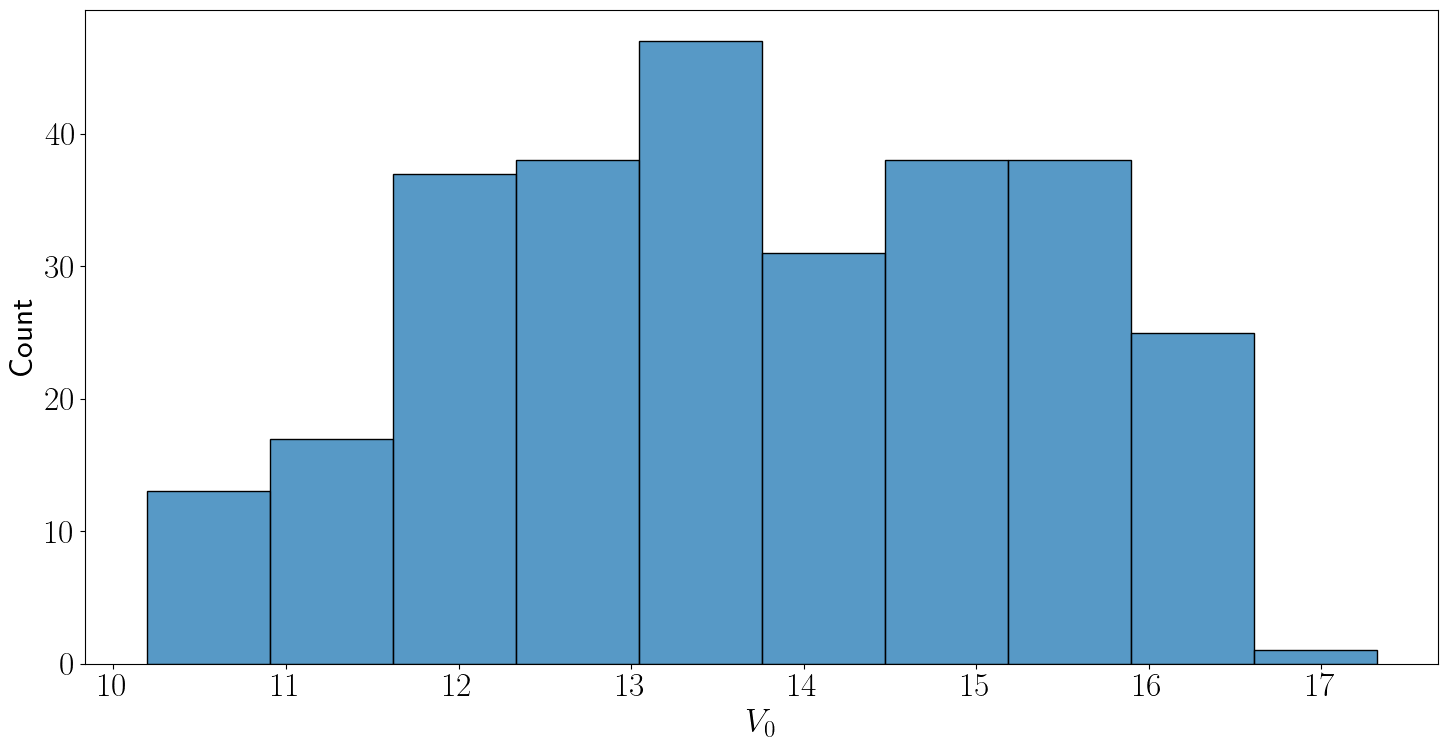

In [10]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

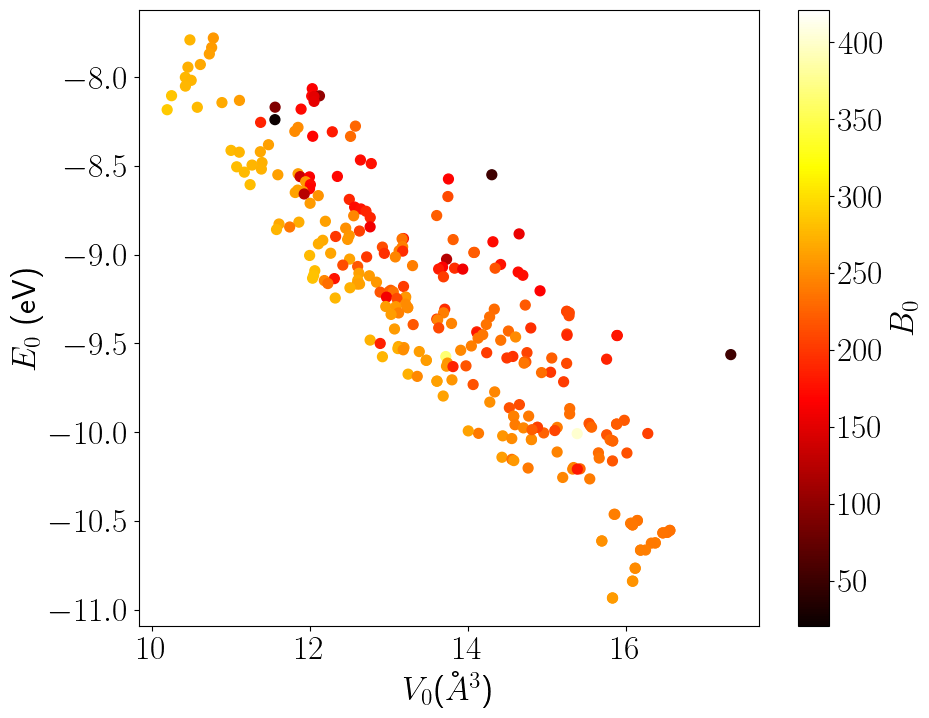

In [11]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = 50, cmap='hot')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])

In [12]:
list(targets.items())[:2]

[('E0', '$E_0$'), ('B0', '$B_0$')]

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Pair Plots

In [13]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

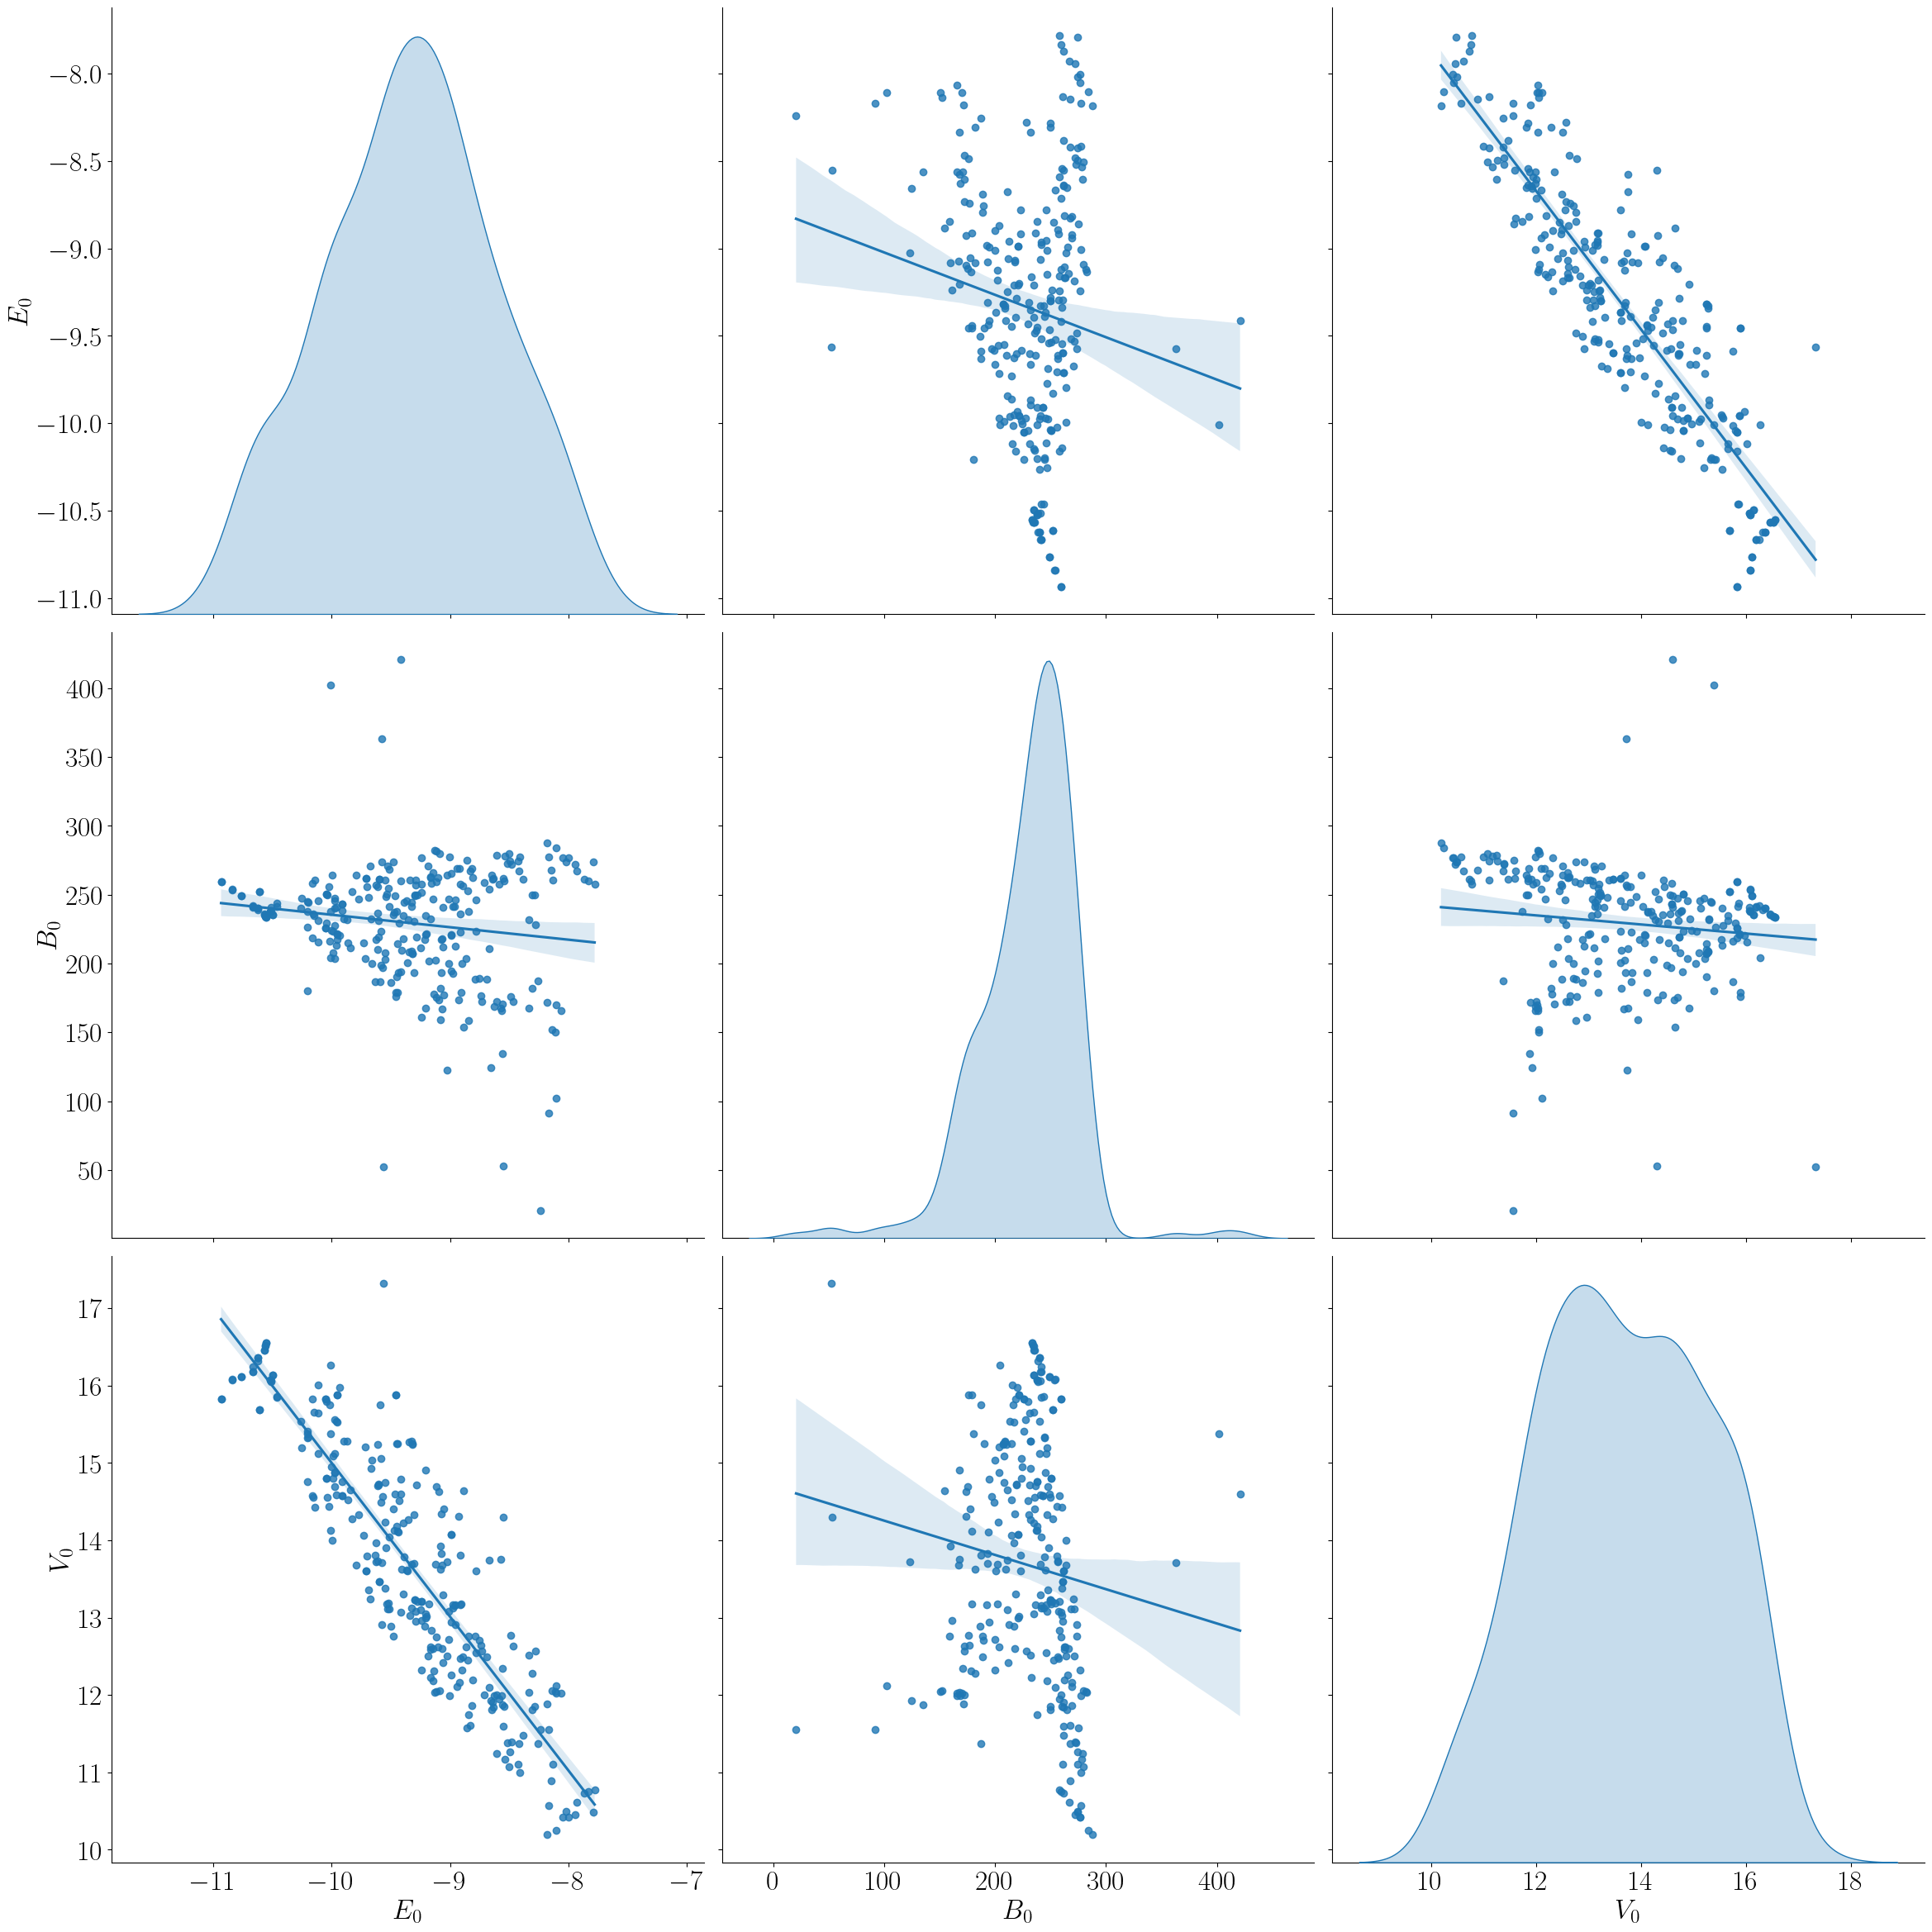

In [14]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [15]:
import pandas as pd
from scipy.spatial import ConvexHull

In [16]:
PhaseBS = {}
verts = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

In [17]:
for phase, bs in PhaseBS.items():
    if bs.shape[0] <= 1:
        continue  # cant make CH with less than 1 sample
    chull = ConvexHull(bs[['Fe_pv','EF']])
    verts[phase] = chull.vertices

In [18]:
irrelevant = ['sigma', 'chi', 'hcp','A15','C15' ,'fcc']

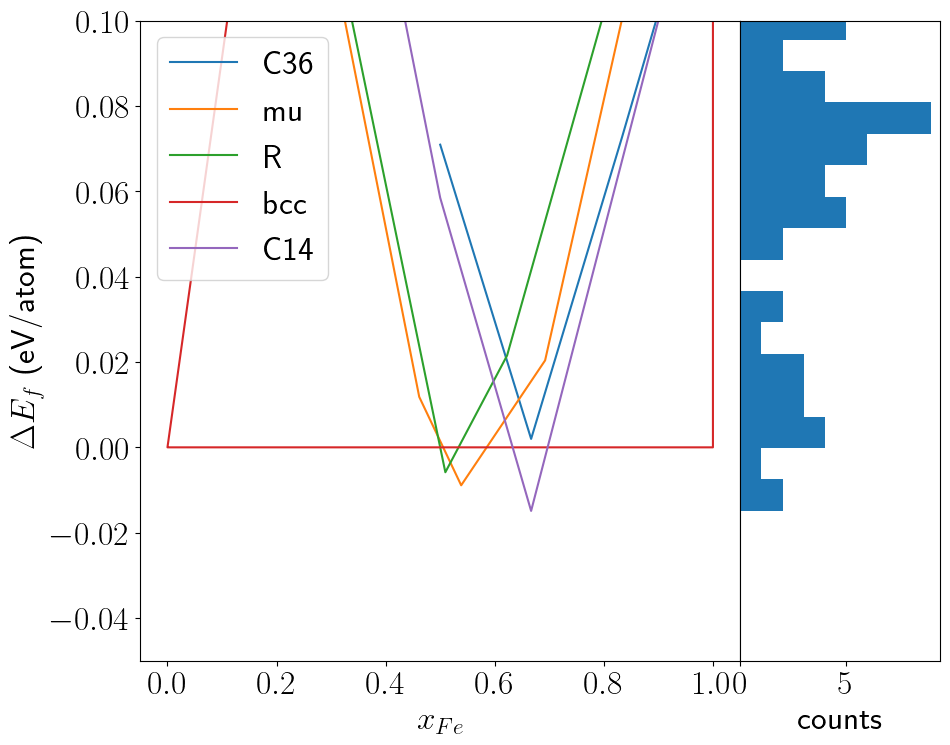

In [19]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    if phase not in irrelevant:
    #    plt.plot(bs['Fe_pv'], bs['EF'], 'o')
        ax.plot(PhaseBS[phase]['Fe_pv'][vertices], PhaseBS[phase]['EF'][vertices], label=phase)
ax.set_ylim([-0.05, 0.1])
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel('$x_{Fe}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()